# EDA: Telco Customer Churn

Análise exploratória do dataset de churn da IBM Telco.  
Objetivo: entender **estrutura**, **qualidade** e **padrões** dos dados antes da modelagem.

| Pilar | O que buscamos |
|---|---|
| Estrutura | Volume, tipos, cardinalidade, composição do dataset |
| Qualidade | Nulos, duplicatas, inconsistências, outliers |
| Padrões | Relações com o target, hipóteses confirmadas ou refutadas |

## 1. Setup

In [1]:
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (10, 4)
sns.set_theme(style="whitegrid")

DATA_PATH = "../data/raw/telco-churn.csv"

CHURN_PALETTE = {"No": "steelblue", "Yes": "tomato"}

## 2. Carregamento dos Dados

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## PILAR 1 - ESTRUTURA

Entender o que temos: volume, tipos de dados, cardinalidade e composição das features.

### 3.1 Tipos e Cardinalidade

In [3]:
info = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notnull().sum(),
    "n_unique": df.nunique(),
    "sample": df.apply(lambda s: s.dropna().unique()[:4].tolist())
})
info

,dtype,non_null,n_unique,sample
customerID,object,7043,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW]"
gender,object,7043,2,"[Female, Male]"
SeniorCitizen,int64,7043,2,"[0, 1]"
Partner,object,7043,2,"[Yes, No]"
Dependents,object,7043,2,"[No, Yes]"
tenure,int64,7043,73,"[1, 34, 2, 45]"
PhoneService,object,7043,2,"[No, Yes]"
MultipleLines,object,7043,3,"[No phone service, No, Yes]"
InternetService,object,7043,3,"[DSL, Fiber optic, No]"
OnlineSecurity,object,7043,3,"[No, Yes, No internet service]"


**Observações de estrutura:**

- **21 colunas** no total: 1 ID (`customerID`), 19 features, 1 target (`Churn`)
- **3 features numéricas contínuas:** `tenure`, `MonthlyCharges`, `TotalCharges`
- **1 pseudo-numérica:** `SeniorCitizen`, codificada como `int64` mas binária categórica (0/1)
- **15 features categóricas** com baixa cardinalidade (2–4 valores únicos)
- `non_null: 7043` para todas as colunas, sem valores ausentes nos dados brutos (à exceção de `TotalCharges`, que tem brancos que só se tornam `NaN` após conversão de tipo)
- `customerID` tem 7043 valores únicos, sem duplicatas de identificador
- `TotalCharges` aparece como `object`, problema de tipo a corrigir na seção de qualidade
- Várias features de serviço têm o valor `"No internet service"` ou `"No phone service"`: são categorias válidas, não nulos

### 3.2 Composição das Features

In [4]:
grupos = {
    "Demográfico": ["gender", "SeniorCitizen", "Partner", "Dependents"],
    "Contrato": ["tenure", "Contract", "PaperlessBilling", "PaymentMethod"],
    "Telefonia": ["PhoneService", "MultipleLines"],
    "Internet": ["InternetService", "OnlineSecurity", "OnlineBackup",
                 "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"],
    "Financeiro": ["MonthlyCharges", "TotalCharges"],
}

for grupo, cols in grupos.items():
    print(f"\n{grupo}: {cols}")


Demográfico: ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

Contrato: ['tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Telefonia: ['PhoneService', 'MultipleLines']

Internet: ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

Financeiro: ['MonthlyCharges', 'TotalCharges']


---
## PILAR 2 - QUALIDADE

Identificar e corrigir problemas antes de qualquer análise de padrões.

### 4.1 Correção de Tipos

In [5]:
# TotalCharges: string -> float. Brancos são clientes novos (tenure=0) -> preencher com 0
print(f"TotalCharges dtype antes : {df['TotalCharges'].dtype}")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
mask_novos = df["TotalCharges"].isnull()
print(f"TotalCharges em branco   : {mask_novos.sum()} registros")
print(f"Todos com tenure=0?      : {df.loc[mask_novos, 'tenure'].eq(0).all()}")
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print(f"TotalCharges dtype depois: {df['TotalCharges'].dtype}")

# Churn: coluna binária auxiliar para análises numéricas
df["Churn_bin"] = (df["Churn"] == "Yes").astype(int)

# Varredura global: NaN restantes e duplicatas
print("\n--- Varredura pós-correção ---")
nulos = df.isnull().sum()
colunas_com_nulo = nulos[nulos > 0]
if colunas_com_nulo.empty:
    print("Nulos: nenhum valor ausente em nenhuma coluna.")
else:
    print("Colunas com nulos:")
    print(colunas_com_nulo)

duplicatas = df.duplicated().sum()
print(f"Duplicatas (linhas completas): {duplicatas}")
print(f"customerID únicos: {df['customerID'].nunique()} de {len(df)} registros")

TotalCharges dtype antes : object
TotalCharges em branco   : 11 registros
Todos com tenure=0?      : True
TotalCharges dtype depois: float64

--- Varredura pós-correção ---
Nulos: nenhum valor ausente em nenhuma coluna.
Duplicatas (linhas completas): 0
customerID únicos: 7043 de 7043 registros


### 4.2 Consistência: `TotalCharges ≈ tenure × MonthlyCharges`

In [6]:
# Esperado: TotalCharges ≈ tenure × MonthlyCharges (pode variar por mudanças de plano)
df["total_esperado"] = df["tenure"] * df["MonthlyCharges"]
df["desvio_total"] = (df["TotalCharges"] - df["total_esperado"]).abs()

# Clientes com tenure > 0 (excluir novos)
df_ativos = df[df["tenure"] > 0]
desvio_mediano = df_ativos["desvio_total"].median()
desvio_pct = (df_ativos["desvio_total"] / df_ativos["total_esperado"] * 100).median()

print(f"Desvio mediano entre TotalCharges real e estimado: ${desvio_mediano:.2f}")
print(f"Desvio relativo mediano: {desvio_pct:.1f}%\n")

df.drop(columns=["total_esperado", "desvio_total"], inplace=True)

Desvio mediano entre TotalCharges real e estimado: $28.65
Desvio relativo mediano: 2.0%



**Interpretação:** desvios pequenos indicam que o plano mensal varia ao longo da vida do cliente. 

### 4.3 Outliers nas Features Numéricas (IQR)

In [7]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

outlier_report = []
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({"feature": col, "Q1": Q1, "Q3": Q3, "IQR": IQR,
                            "lower": lower, "upper": upper, "outliers": n_out})

pd.DataFrame(outlier_report).set_index("feature").round(2)

,Q1,Q3,IQR,lower,upper,outliers
feature,,,,,,
tenure,9.00,55.00,46.00,-60.00,124.00,0
MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0
TotalCharges,398.55,3786.60,3388.05,-4683.52,8868.67,0


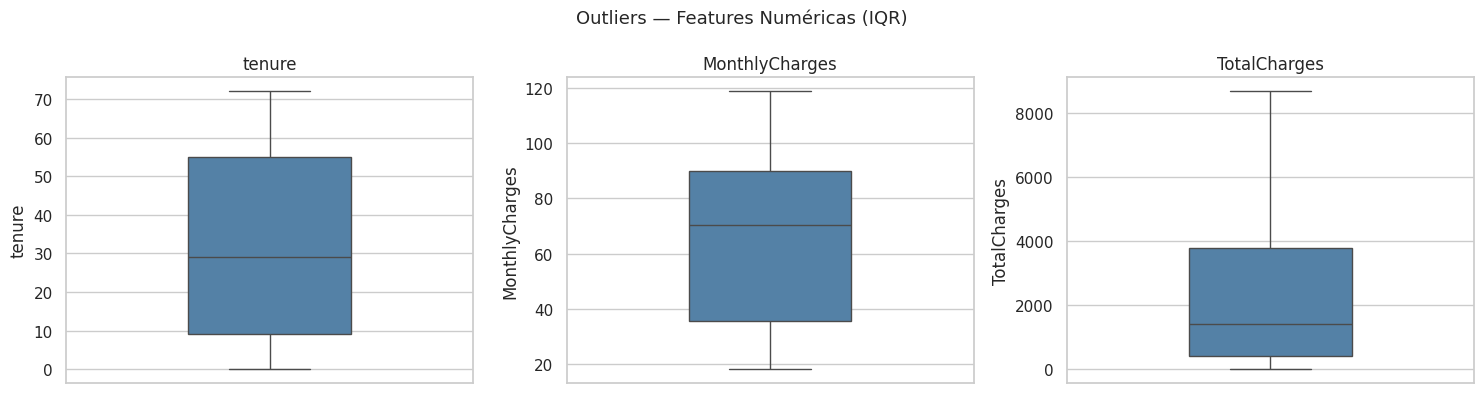

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, y=col, ax=ax, color="steelblue", width=0.4)
    ax.set_title(f"{col}")
plt.suptitle("Outliers — Features Numéricas (IQR)", fontsize=13)
plt.tight_layout()
plt.show()

**Observação:** ausência de outliers extremos, distribuições naturais do negócio.

### 4.4 Valores Impossíveis de Domínio

In [9]:
regras = {
    "tenure >= 0":        (df["tenure"] >= 0,        "tenure"),
    "MonthlyCharges > 0": (df["MonthlyCharges"] > 0, "MonthlyCharges"),
    "TotalCharges >= 0":  (df["TotalCharges"] >= 0,  "TotalCharges"),
}

rows = []
todas_ok = True
violacoes_dfs = {}

for regra, (mascara, col) in regras.items():
    n_violacoes = int((~mascara).sum())
    rows.append({
        "Regra": regra,
        "Violações": n_violacoes,
        "Mínimo": df[col].min(),
        "Máximo": df[col].max(),
        "Status": "OK" if n_violacoes == 0 else "VIOLAÇÃO",
    })
    if n_violacoes > 0:
        todas_ok = False
        violacoes_dfs[regra] = df[~mascara][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

resultado = pd.DataFrame(rows).set_index("Regra")

def _colorir_status(val):
    if val == "OK":
        return "color: green; font-weight: bold"
    return "color: crimson; font-weight: bold"

display(
    resultado.style
    .format({"Mínimo": "{:.2f}", "Máximo": "{:.2f}"})
    .map(_colorir_status, subset=["Status"])
)

if todas_ok:
    print("\nNenhuma violação de domínio encontrada.")
else:
    print("\nInvestigar violações abaixo antes de modelar.")
    for regra, vdf in violacoes_dfs.items():
        print(f"\nViolações — {regra}:")
        display(vdf)


,Violações,Mínimo,Máximo,Status
Regra,,,,
tenure >= 0,0,0.00,72.00,OK
MonthlyCharges > 0,0,18.25,118.75,OK
TotalCharges >= 0,0,0.00,8684.80,OK



Nenhuma violação de domínio encontrada.


---
## PILAR 3 - PADRÕES

Identificar relações com o target, testar hipóteses e descobrir padrões que guiarão o modelo.

**Hipóteses a testar:**
- H1: Clientes com contrato mensal churnam muito mais que contratos anuais/bienais
- H2: Tempo de permanência (`tenure`) é inversamente relacionado ao churn
- H3: Clientes de Fiber Optic têm maior churn (custo mais alto, mais concorrência)
- H4: Ausência de serviços de segurança/suporte está associada a maior churn
- H5: Clientes idosos (`SeniorCitizen`) têm maior taxa de churn
- H6: `MonthlyCharges` alto está associado a maior churn

### 5.1 Variável Alvo

Distribuição de Churn:
  No: 5,174 (73.5%)
  Yes: 1,869 (26.5%)


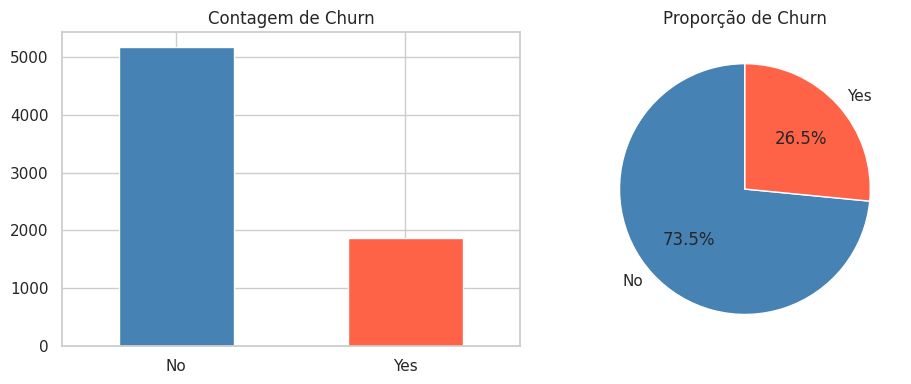

In [10]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print("Distribuição de Churn:")
for label in ["No", "Yes"]:
    print(f"  {label}: {churn_counts[label]:,} ({churn_pct[label]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
churn_counts.plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="white")
axes[0].set_title("Contagem de Churn")
axes[0].tick_params(axis="x", rotation=0)
axes[0].set_xlabel("")

axes[1].pie(churn_counts, labels=churn_counts.index, autopct="%1.1f%%",
            colors=["steelblue", "tomato"], startangle=90)
axes[1].set_title("Proporção de Churn")
plt.tight_layout()
plt.show()

**Desbalanceamento (~27% churn):** a divisão aleatória de folds pode distorcer a proporção por acaso: um fold poderia ter 14% de churns em vez de 27%, fazendo o modelo aprender e ser avaliado em distribuições irreais. A validação cruzada **estratificada** garante que cada fold reflita a proporção original, tornando as métricas confiáveis.

**Escolha de métricas:** com classes desbalanceadas, accuracy é enganosa: um modelo que chuta "não churn" para todo mundo acerta ~73% das vezes sem detectar nenhum churn. Métricas prioritárias:

- **F1:** penaliza quando o modelo ignora a classe minoritária, buscando equilíbrio entre precisão e recall dos churns
- **PR-AUC:** foca exclusivamente na classe positiva; insensível ao volume de negativos, que aqui é grande
- **AUC-ROC:** útil para discriminação geral, mas pode ser otimista, pois o volume alto de verdadeiros negativos infla a curva

### 5.2 Distribuição das Features Numéricas por Churn

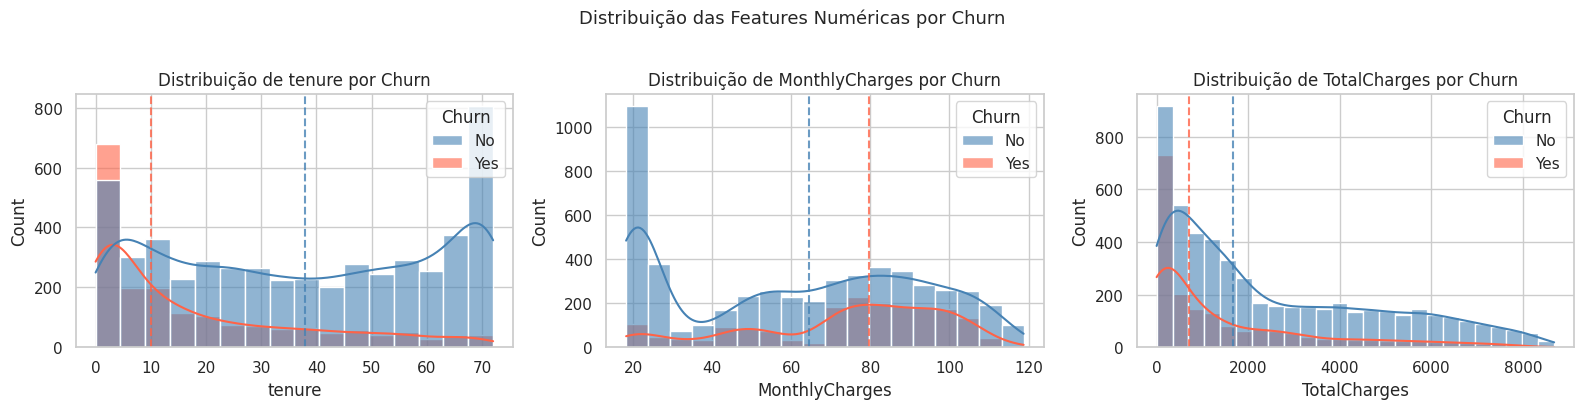

,Mediana (ficou),Mediana (churnou),Variação (%)
Feature,,,
tenure,38.00,10.00,-73.7%
MonthlyCharges,64.43,79.65,+23.6%
TotalCharges,1679.53,703.55,-58.1%


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=ax,
                 palette=CHURN_PALETTE, alpha=0.6)
    medians = df.groupby("Churn")[col].median()
    for label, color in CHURN_PALETTE.items():
        ax.axvline(medians[label], color=color, linestyle="--", alpha=0.8)
    ax.set_title(f"Distribuição de {col} por Churn")

plt.suptitle("Distribuição das Features Numéricas por Churn", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

medians_df = df.groupby("Churn")[num_cols].median().T
medians_df.columns.name = None
medians_df.index.name = "Feature"
medians_df = medians_df.rename(columns={"No": "Mediana (ficou)", "Yes": "Mediana (churnou)"})
medians_df["Variação (%)"] = (
    (medians_df["Mediana (churnou)"] - medians_df["Mediana (ficou)"])
    / medians_df["Mediana (ficou)"] * 100
).round(1)

medians_df.style.format({
    "Mediana (ficou)": "{:.2f}",
    "Mediana (churnou)": "{:.2f}",
    "Variação (%)": "{:+.1f}%",
})


Clientes que cancelaram tinham, em mediana, **tenure 74% menor**: chegaram há pouco no serviço e já foram embora. Apesar disso, pagavam **24% a mais por mês**, o que sugere insatisfação com o custo-benefício. O `TotalCharges` baixo dos churners é consequência direta do tenure curto, não uma causa independente.

### 5.3 H1: Tipo de Contrato e Churn

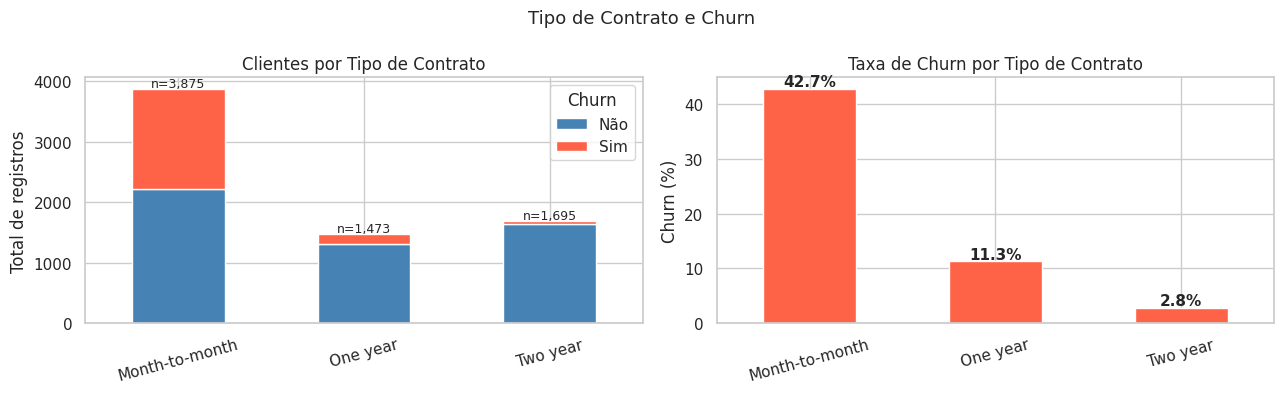

In [12]:
contrato_counts = df.groupby(["Contract", "Churn"]).size().unstack(fill_value=0)[["No", "Yes"]]
ordem = (contrato_counts["Yes"] / contrato_counts.sum(axis=1)).sort_values(ascending=False).index
contrato_counts = contrato_counts.loc[ordem]
taxa_contrato = contrato_counts["Yes"] / contrato_counts.sum(axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

contrato_counts.plot(kind="bar", stacked=True, ax=axes[0],
                     color=["steelblue", "tomato"], edgecolor="white")
axes[0].set_title("Clientes por Tipo de Contrato")
axes[0].set_ylabel("Total de registros")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(title="Churn", labels=["Não", "Sim"])
for i, total in enumerate(contrato_counts.sum(axis=1)):
    axes[0].text(i, total + 30, f"n={total:,}", ha="center", fontsize=9)

taxa_contrato.plot(kind="bar", ax=axes[1], color="tomato", edgecolor="white")
axes[1].set_title("Taxa de Churn por Tipo de Contrato")
axes[1].set_ylabel("Churn (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(taxa_contrato):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Tipo de Contrato e Churn", fontsize=13)
plt.tight_layout()
plt.show()

**H1 confirmada:** Clientes com contrato **mês a mês cancelam a uma taxa de 43%**, aproximadamente quatro vezes a taxa dos contratos anuais (11%) e quatorze vezes a dos bienais (3%). Apesar de ser o tipo de contrato mais comum (n=3.875), é também onde a operadora perde mais clientes. Pode-se deduzir que contratos de longo prazo funcionam como âncora de retenção: ao comprometer o cliente por um período, reduzem drasticamente a janela de decisão de cancelamento.

### 5.4 H2: Tenure e Churn (cliente que fica, fica)

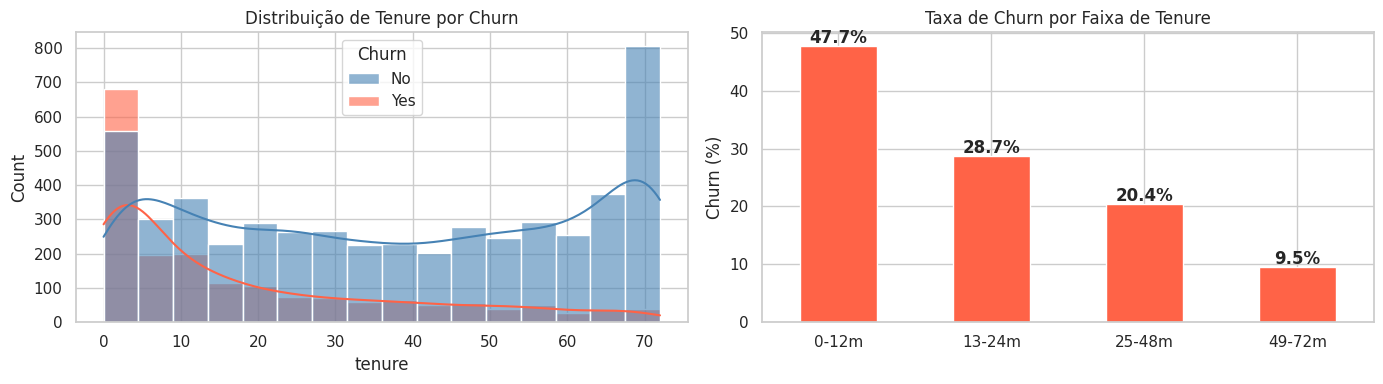

Correlação Pearson (tenure, Churn): -0.352


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribuição de tenure por churn
sns.histplot(data=df, x="tenure", hue="Churn", kde=True, ax=axes[0],
             palette=CHURN_PALETTE, alpha=0.6)
axes[0].set_title("Distribuição de Tenure por Churn")

# Taxa de churn por faixa de tenure
df["tenure_faixa"] = pd.cut(df["tenure"], bins=[0, 12, 24, 48, 72],
                             labels=["0-12m", "13-24m", "25-48m", "49-72m"])
taxa_tenure = df.groupby("tenure_faixa", observed=True)["Churn_bin"].mean() * 100
taxa_tenure.plot(kind="bar", ax=axes[1], color="tomato", edgecolor="white")
axes[1].set_title("Taxa de Churn por Faixa de Tenure")
axes[1].set_ylabel("Churn (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(taxa_tenure):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

corr_tenure = df["tenure"].corr(df["Churn_bin"])
print(f"Correlação Pearson (tenure, Churn): {corr_tenure:.3f}")

**H2 confirmada:** A correlação de Pearson de **-0.352** e os gráficos mostram que a relação entre tenure e churn é inversa e moderada. O sinal negativo indica que tenure alto está associado a churn baixo. A magnitude (0.35) não é forte o suficiente para ser a única feature do modelo, mas é um sinal claro, especialmente visível no gráfico de faixas, onde a taxa cai de 47.7% no primeiro ano para 9.5% após 4 anos.

### 5.5 H3: Internet Service e Churn

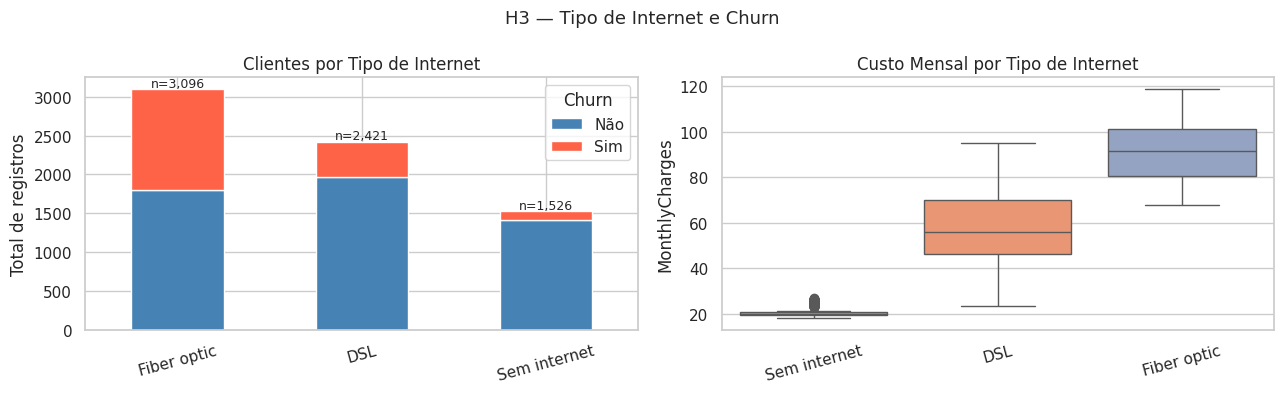

In [14]:
label_map = {"No": "Sem internet", "DSL": "DSL", "Fiber optic": "Fiber optic"}
df["InternetService_label"] = df["InternetService"].map(label_map)

internet_counts = df.groupby(["InternetService_label", "Churn"]).size().unstack(fill_value=0)[["No", "Yes"]]
ordem = (internet_counts["Yes"] / internet_counts.sum(axis=1)).sort_values(ascending=False).index
internet_counts = internet_counts.loc[ordem]
taxa_internet = internet_counts["Yes"] / internet_counts.sum(axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

internet_counts.plot(kind="bar", stacked=True, ax=axes[0],
                     color=["steelblue", "tomato"], edgecolor="white")
axes[0].set_title("Clientes por Tipo de Internet")
axes[0].set_ylabel("Total de registros")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(title="Churn", labels=["Não", "Sim"])
for i, total in enumerate(internet_counts.sum(axis=1)):
    axes[0].text(i, total + 30, f"n={total:,}", ha="center", fontsize=9)

sns.boxplot(data=df, x="InternetService_label", y="MonthlyCharges", ax=axes[1],
            palette="Set2", order=["Sem internet", "DSL", "Fiber optic"])
axes[1].set_title("Custo Mensal por Tipo de Internet")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("H3 — Tipo de Internet e Churn", fontsize=13)
plt.tight_layout()
plt.show()


**H3 confirmada:** Fiber Optic concentra **42% de taxa de churn**, mais que o dobro do DSL (19%) e sete vezes mais que clientes sem internet (7%). O gráfico de custo mensal explica em parte esse padrão: Fiber Optic é consistentemente o serviço mais caro, com mediana bem acima dos demais. A combinação de alto churn e alto custo levanta a hipótese de percepção negativa de custo-benefício, mas os dados sozinhos não confirmam a causa.

### 5.6 H4: Serviços de Segurança/Suporte e Churn

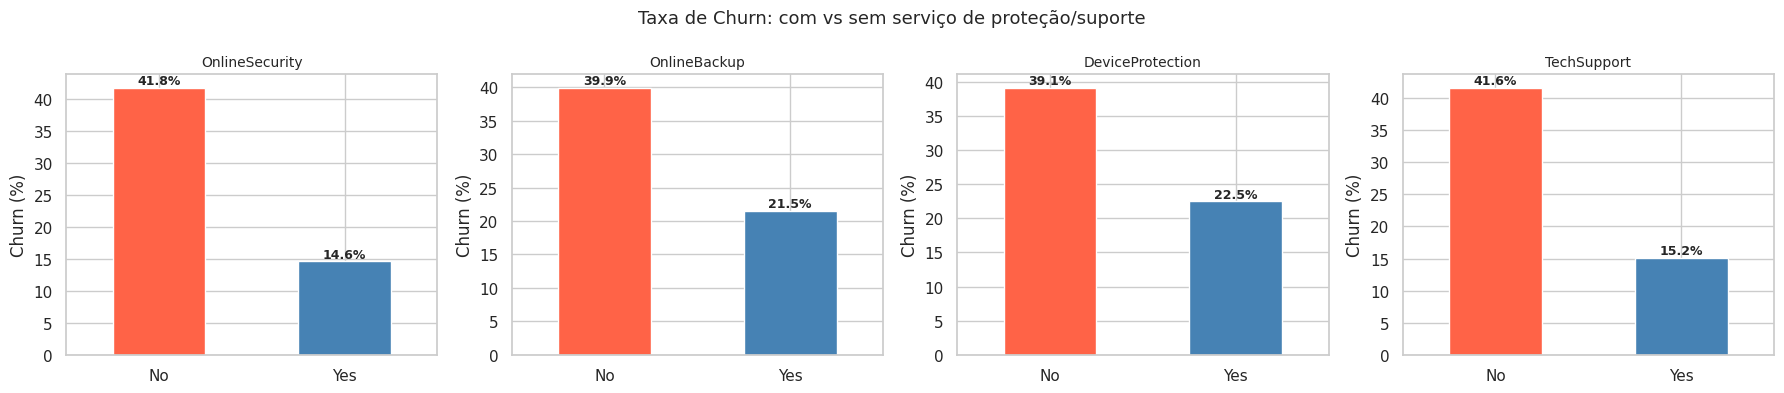

In [15]:
servicos = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, servicos):
    taxa = df[df[col] != "No internet service"].groupby(col)["Churn_bin"].mean() * 100
    taxa = taxa.reindex(["No", "Yes"])
    taxa.plot(kind="bar", ax=ax, color=["tomato", "steelblue"], edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Churn (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    for i, v in enumerate(taxa):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Taxa de Churn: com vs sem serviço de proteção/suporte", fontsize=13)
plt.tight_layout()
plt.show()

**H4 confirmada:** Clientes sem serviços de proteção e suporte cancelam a uma taxa aproximadamente **duas vezes maior** que clientes com esses serviços. `OnlineSecurity` e `TechSupport` são os mais discriminativos, com diferença de até ~25 pp entre quem tem e quem não tem o serviço. A presença de qualquer serviço adicional funciona como âncora de retenção, provavelmente porque aumenta a percepção de valor e o custo de troca do cliente.

### 5.7 H5: Senioridade e Churn

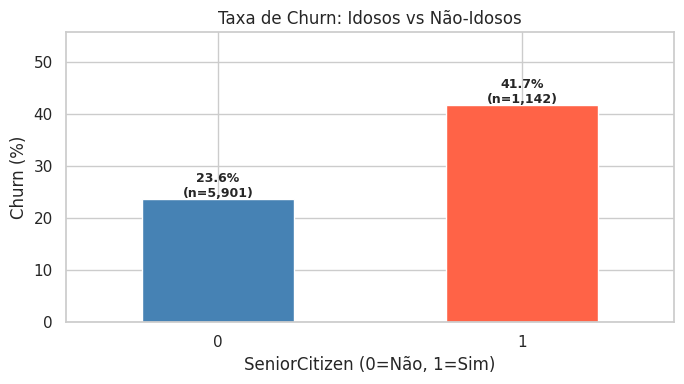

In [16]:
taxa_senior = df.groupby("SeniorCitizen")["Churn_bin"].mean() * 100
contagem_senior = df.groupby("SeniorCitizen")["Churn_bin"].count()

fig, ax = plt.subplots(figsize=(7, 4))
taxa_senior.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="white")
ax.set_title("Taxa de Churn: Idosos vs Não-Idosos")
ax.set_ylabel("Churn (%)")
ax.set_xlabel("SeniorCitizen (0=Não, 1=Sim)")
ax.set_ylim(0, taxa_senior.max() + 14)
ax.tick_params(axis="x", rotation=0)
for i, (v, n) in enumerate(zip(taxa_senior, contagem_senior)):
    ax.text(i, v + 0.5, f"{v:.1f}%\n(n={n:,})", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

**H5 confirmada:** Clientes idosos churnam a **41,7%**, quase o dobro dos não-idosos (24,6%). No entanto, representam apenas ~16% da base (n=1.142), então o impacto absoluto no volume de cancelamentos é limitado.

### 5.8 H6: Custo Mensal e Churn

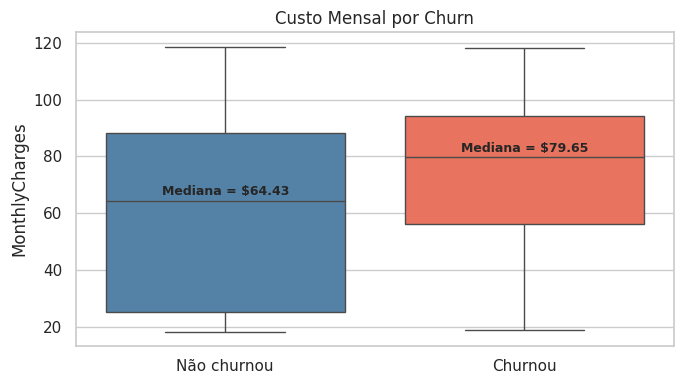

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=ax,
            palette=CHURN_PALETTE, order=["No", "Yes"])
ax.set_title("Custo Mensal por Churn")
ax.set_xlabel("")
ax.set_xticklabels(["Não churnou", "Churnou"])

medians = df.groupby("Churn")["MonthlyCharges"].median()
for i, churn_val in enumerate(["No", "Yes"]):
    med = medians[churn_val]
    ax.text(i, med + 2, f"Mediana = ${med:.2f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

**H6 Confirmada:** Clientes que cancelaram pagavam em mediana **\$79.65/mês**, contra **\$64.43** dos que ficaram, uma diferença de **~24%**. A distribuição dos churners está deslocada para valores mais altos, indicando que planos mais caros estão associados a maior risco de cancelamento. Combinado com o resultado do H3, isso reforça que Fiber Optic, o serviço mais caro, contribui para esse padrão.

### 5.9 Interação: Contract × Tenure (o padrão mais forte)

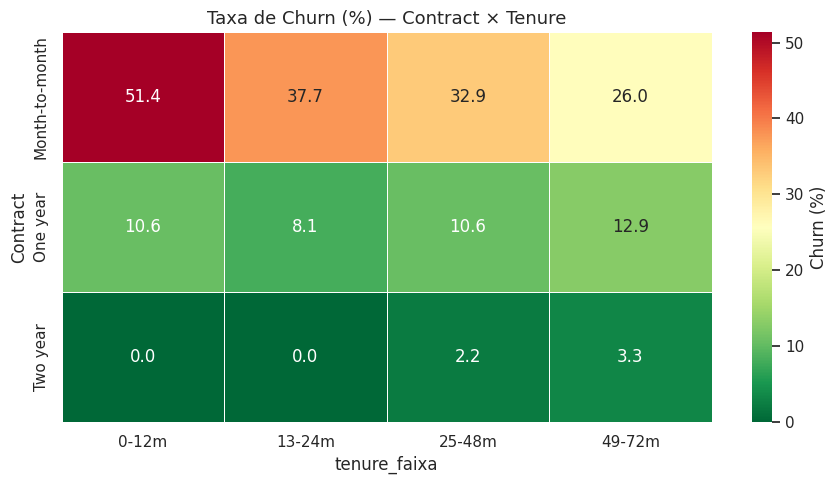

In [18]:
pivot = df.groupby(["Contract", "tenure_faixa"], observed=True)["Churn_bin"].mean() * 100
pivot = pivot.unstack()

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
            linewidths=0.5, cbar_kws={"label": "Churn (%)"})
plt.title("Taxa de Churn (%) — Contract × Tenure", fontsize=13)
plt.tight_layout()
plt.show()

Clientes com contrato **mês a mês e até 12 meses de tenure** são o grupo de maior risco, com taxa de churn acima de **51%**. A interação entre `Contract` e `tenure` é um padrão muito forte do dataset. Contratos anuais e bienais eliminam quase completamente o risco mesmo nos primeiros meses; o tipo de contrato é o fator de proteção mais eficaz.

### 5.10 Força de Associação com Churn: Cramér's V (Categóricas)

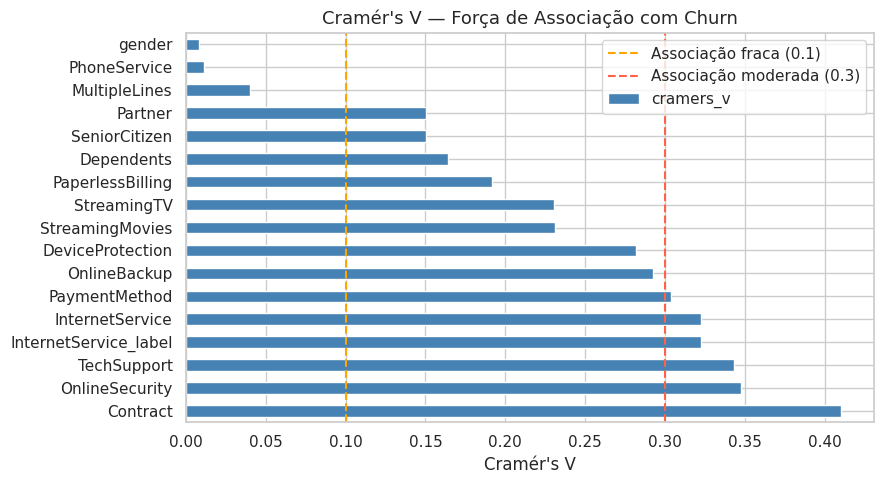

In [19]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# tenure_faixa é Categorical (não object), então não aparece no select_dtypes
cat_cols = df.select_dtypes(include="object").columns.drop(["customerID", "Churn"]).tolist()
cols_para_testar = cat_cols + ["SeniorCitizen"]

associacoes = {col: cramers_v(df[col].astype(str), df["Churn"]) for col in cols_para_testar}
assoc_df = pd.Series(associacoes).sort_values(ascending=False).to_frame("cramers_v")

fig, ax = plt.subplots(figsize=(9, 5))
assoc_df["cramers_v"].plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.axvline(0.1, color="orange", linestyle="--", label="Associação fraca (0.1)")
ax.axvline(0.3, color="tomato", linestyle="--", label="Associação moderada (0.3)")
ax.set_title("Cramér's V — Força de Associação com Churn", fontsize=13)
ax.set_xlabel("Cramér's V")
ax.legend()
plt.tight_layout()
plt.show()

O gráfico mede o Cramér's V entre **cada feature categórica e o target `Churn`**: é um ranking de associação que consolida em um único número o quanto cada variável "separa" quem cancela de quem fica. Valores acima de 0,3 indicam associação moderada a forte.

`Contract` lidera com folga, confirmando H1 como o sinal mais forte do dataset. `InternetService`, `OnlineSecurity` e `TechSupport` aparecem logo depois, coerentes com H3 e H4. Features demográficas como `gender` e `PhoneService` ficam próximas de zero, com pouca ou nenhuma associação com churn. Esse ranking ajuda a entender as hipóteses e quais features merecem mais peso no pipeline de modelagem.

### 5.11 Correlação entre Features Numéricas e Churn

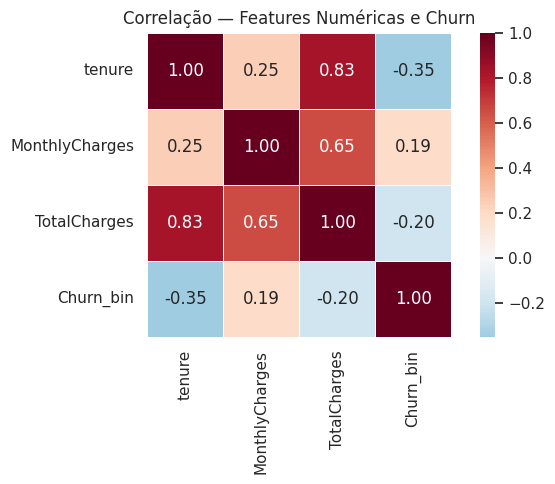

In [20]:
corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_bin"]
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5)
plt.title("Correlação — Features Numéricas e Churn")
plt.tight_layout()
plt.show()

`TotalCharges` tem correlação de **+0,83 com `tenure`**: clientes antigos naturalmente acumulam mais cobranças, então as duas variáveis carregam informação parecida. Isso é multicolinearidade; incluir ambas no modelo pode inflar coeficientes e dificultar a interpretação. O pipeline de pré-processamento deve lidar com isso, seja removendo `TotalCharges`, seja aplicando PCA.

Em relação ao churn, `tenure` é o sinal numérico mais forte (−0,35): quanto mais tempo o cliente fica, menor a chance de cancelar. `MonthlyCharges` tem correlação positiva (+0,19), confirmando H6. `TotalCharges` aparece com correlação negativa (−0,20), mas isso é efeito colateral de sua alta correlação com `tenure`, não sendo um sinal independente.

---
## 6. Data Readiness - Resumo Final

### Estrutura

| | |
|---|---|
| Registros | 7.043 |
| Features | 19 (excluindo `customerID`) + 1 target (`Churn`) |
| Numéricas contínuas | `tenure`, `MonthlyCharges`, `TotalCharges` |
| Categóricas | 15 features com cardinalidade 2–4 + `SeniorCitizen` (binário codificado como `int`) |
| Desbalanceamento | 73,5% não churnou / 26,5% churnou; validação cruzada estratificada obrigatória |

### Qualidade

| Problema | Tratamento |
|---|---|
| `TotalCharges` como `object` | Convertido para `float64`: 11 brancos (clientes com `tenure = 0`) preenchidos com 0 |
| Nulos | Nenhum após correção |
| Duplicatas | Nenhuma; 7.043 `customerID` únicos |
| Outliers | Nenhum extremo via IQR; distribuições naturais do negócio |
| Consistência `TotalCharges` | Desvio mediano de 2% em relação a `tenure × MonthlyCharges`; esperado por variação histórica de plano |

### Padrões: Hipóteses

| Hipótese | Resultado | Evidência |
|---|---|---|
| H1: Contrato mensal → mais churn | ✅ Confirmada | 43% vs 11% (anual) vs 3% (bienal) |
| H2: Tenure alto → menos churn | ✅ Confirmada | Correlação −0,35; taxa cai de 47,7% (0–12m) para 9,5% (>4 anos) |
| H3: Fiber Optic → mais churn | ✅ Confirmada | 42% vs 19% (DSL) vs 7% (sem internet) |
| H4: Sem serviços de proteção → mais churn | ✅ Confirmada | ~2× mais churn; `OnlineSecurity` e `TechSupport` mais discriminativos |
| H5: Idosos → mais churn | ✅ Confirmada | 41,7% vs 24,6%, mas apenas ~16% da base |
| H6: `MonthlyCharges` alto → mais churn | ✅ Confirmada | Mediana \$79.65 (churnou) vs \$64.43 (ficou) |

**Padrão mais forte:** clientes com contrato mês a mês e `tenure < 12m` atingem mais de **51% de churn**; nenhuma feature isolada captura esse risco tão claramente quanto a combinação `Contract × tenure`.

**Atenção para modelagem:** `TotalCharges` tem correlação de +0,83 com `tenure`, caracterizando multicolinearidade que deve ser tratada no pipeline (remoção ou PCA). Features demográficas (`gender`, `PhoneService`) têm associação próxima de zero com o target.